# El Problema de la Inacción: Agua, Salud y Pobreza en Ciudad de México
**Equipo:** Calidad de Datos (Carlo Kiliano Ferrera, José Julian Pérez, Aldo Sebastián Altamirano)  
**IIMAS UNAM 2026 - Licenciatura en Cienncia de Datos**

> *"Limpiar el agua es lo que necesita el México de hoy: la inacción es más cara."*

# Perfilado
Este notebook documenta el proceso de Perfilado de datos para ver con que empezaremos a trabajar para demostrar la relación causal entre tres Objetivos de Desarrollo Sostenible (ODS):
1. **ODS 6 (Agua y Saneamiento):** El origen físico de la toxicidad en cuerpos de agua superficiales.
2. **ODS 3 (Salud y Bienestar):** El impacto biológico reflejado en la morbilidad por enfermedades gastrointestinales.
3. **ODS 1 (Fin de la Pobreza):** La vulnerabilidad de infraestructura y la trampa económica que representan los gastos médicos para familias marginadas.

## 1 Instalacion Librerias y Preparacion Entorno

In [1]:
# Instalar librerías necesarias
#!pip install pyxlsb openpyxl
#!pip install pdfplumber pandas
#!pip install chardet
#!pip install missingno

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pdfplumber
import chardet
import missingno as msno

In [2]:
from pathlib import Path

def get_project_root(marker='README.md'):
    current = Path.cwd()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError("No se encontró la raíz")

PROJECT_ROOT = get_project_root()

print(PROJECT_ROOT)

c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos


## 2 Nuestro modelo canonico (CSV)

### 2.1 PDF a CSV

In [3]:
def extraer_tabla_pdf(archivo_pdf, salida_csv="plantas_cdmx.csv"):
    todas_filas = []
    encabezado = None
    
    with pdfplumber.open(archivo_pdf) as pdf:
        for num_pag, pagina in enumerate(pdf.pages, start=1):
            print(f"Procesando página {num_pag}...")
            tabla = pagina.extract_table()
            
            if not tabla:
                print(f"  No se encontró tabla en página {num_pag}")
                continue
            
            # Primera página: capturar encabezado
            if num_pag == 1:
                encabezado = tabla[0]
                datos_pagina = tabla[1:]   # omitimos el encabezado
            else:
                # Si la primera fila es igual al encabezado, la saltamos
                if tabla and tabla[0] == encabezado:
                    datos_pagina = tabla[1:]
                else:
                    datos_pagina = tabla
            
            print(f"  Encontradas {len(datos_pagina)} filas de datos")
            todas_filas.extend(datos_pagina)
    
    if not todas_filas:
        print("No se extrajo ninguna fila.")
        return None
    
    # Crear DataFrame
    df = pd.DataFrame(todas_filas, columns=encabezado)
    
    # Eliminar fila de total (si existe)
    df = df[~df.iloc[:, 0].astype(str).str.contains("Total", case=False, na=False)]
    df = df.dropna(how="all")
    
    # Limpiar espacios en blanco
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x)
    
    # Convertir columnas numéricas (suponiendo nombres en el PDF)
    for col in df.columns:
        if "l/s" in col or "Capacidad" in col or "Caudal" in col:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Guardar CSV
    df.to_csv(salida_csv, index=False, encoding="utf-8-sig")
    print(f"\n✅ CSV guardado: {salida_csv}")
    print(f"Total de plantas extraídas: {len(df)}")
    return df

In [4]:
# PDF convertir a csv
archivo_pdf = PROJECT_ROOT / "datos" / "datos_crudos" / "Inventario_Nacional_PPyPATAR_2024_CDMX.pdf"

# Ruta completa del CSV de salida (misma carpeta de datos crudos)
ruta_salida_csv = PROJECT_ROOT / "datos" / "datos_crudos" / "plantas_cdmx.csv"

# Convertir a string porque la función espera str
df_plantas = extraer_tabla_pdf(str(archivo_pdf), str(ruta_salida_csv))

Procesando página 1...
  Encontradas 18 filas de datos
Procesando página 2...
  Encontradas 18 filas de datos
Procesando página 3...
  Encontradas 10 filas de datos

✅ CSV guardado: c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos\datos\datos_crudos\plantas_cdmx.csv
Total de plantas extraídas: 45


### 2.2 XML a CSV

In [12]:
import xml.etree.ElementTree as ET
import pandas as pd

#Ruta archivo de entrada
ruta_archivo_xml = PROJECT_ROOT / "datos" / "datos_crudos" / "Ciudad de México.xml"

# Ruta completa del CSV de salida (misma carpeta de datos crudos)
ruta_salida_csv = PROJECT_ROOT / "datos" / "datos_crudos" / "catalogo_sepomex.csv"

tree = ET.parse(ruta_archivo_xml)
root = tree.getroot()

# Namespace definido en el XML
ns = {'ns': 'NewDataSet'}

datos = []
for table in root.findall('.//ns:table', ns):
    registro = {}
    for child in table:
        # Quitar el prefijo del namespace en el tag
        tag = child.tag.split('}')[-1] if '}' in child.tag else child.tag
        registro[tag] = child.text
    datos.append(registro)

df = pd.DataFrame(datos)

# Guardar CSV
df.to_csv(ruta_salida_csv, index=False, encoding="utf-8-sig")
print(f"\n✅ CSV guardado: {ruta_salida_csv}")


✅ CSV guardado: c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos\datos\datos_crudos\catalogo_sepomex.csv


In [14]:
# ------------------------------------------------------------
# Seleccionar y renombrar las columnas según tu formato
# ------------------------------------------------------------
catalogo = df[['d_estado', 'c_estado', 'D_mnpio', 'c_mnpio', 'd_asenta', 'd_codigo']].copy()
catalogo.columns = [
    'nom_estado',      # → "Ciudad de México"
    'cve_estado',      # → "09"
    'nom_alcaldia',    # nombre del municipio/alcaldía
    'cve_alcaldia',    # clave del municipio (3 dígitos)
    'nom_colonia',     # nombre del asentamiento/colonia
    'codigo_postal'    # código postal del asentamiento (5 dígitos)
]

# Eliminar registros duplicados (misma combinación alcaldía + colonia + CP)
catalogo = catalogo.drop_duplicates()

# Formatear claves con ceros a la izquierda (estético, pero recomendable)
catalogo['cve_estado']    = catalogo['cve_estado'].astype(str).str.zfill(2)
catalogo['cve_alcaldia']  = catalogo['cve_alcaldia'].astype(str).str.zfill(3)
catalogo['codigo_postal'] = catalogo['codigo_postal'].astype(str).str.zfill(5)

# Guardar CSV
catalogo.to_csv(ruta_salida_csv, index=False, encoding="utf-8-sig")
print(f"\n CSV guardado: {ruta_salida_csv}")

print(f"Catálogo generado con {len(catalogo)} registros.")
print("Columnas:", catalogo.columns.tolist())


 CSV guardado: c:\Users\PC\Desktop\Antigravity\ProyectoFinal_CalidadDatos\datos\datos_crudos\catalogo_sepomex.csv
Catálogo generado con 1526 registros.
Columnas: ['nom_estado', 'cve_estado', 'nom_alcaldia', 'cve_alcaldia', 'nom_colonia', 'codigo_postal']


## 3 Perfilado General

In [3]:
import os
import pandas as pd
import chardet
from pathlib import Path

ruta = PROJECT_ROOT / 'datos' / 'datos_crudos'

# Obtener solo archivos de interés
archivos = [f for f in os.listdir(ruta) if f.endswith(('.xlsx', '.xls', '.csv', '.xlsb'))]

print(f"Procesando {len(archivos)} archivos...\n")

for archivo in archivos:
    path_completo = os.path.join(ruta, archivo)
    try:
        if archivo.endswith('.csv'):
            # --- Detectar la codificación real del archivo ---
            with open(path_completo, 'rb') as f:
                raw_data = f.read(200000)  # Leer una muestra (200KB para mejor detección)
                resultado = chardet.detect(raw_data)
                encoding_detectado = resultado['encoding']
                confianza = resultado['confidence']
            
            # Intentar leer con la codificación detectada, con fallback
            try:
                df_headers = pd.read_csv(path_completo, encoding=encoding_detectado, low_memory=False)
                print(f"📄 Archivo: {archivo}")
                print(f"🔤 Codificación usada: {encoding_detectado} (confianza: {confianza:.2%})")
            except (UnicodeDecodeError, LookupError):
                # Fallback: latin-1 nunca falla porque mapea todos los bytes 0x00-0xFF
                df_headers = pd.read_csv(path_completo, encoding='latin-1', low_memory=False)
                print(f"📄 Archivo: {archivo}")
                print(f"⚠️ Codificación detectada ({encoding_detectado}) falló → se usó latin-1 como fallback")
        
        elif archivo.endswith('.xlsb'):
            df_headers = pd.read_excel(path_completo, engine='pyxlsb')
            print(f"📄 Archivo: {archivo}")
            print(f"🔤 Codificación: no aplica (archivo binario)")
        
        else:  # .xlsx, .xls
            df_headers = pd.read_excel(path_completo)
            print(f"📄 Archivo: {archivo}")
            print(f"🔤 Codificación: no aplica (archivo binario)")
        
        # Mostrar información común
        print(f"📊 Columnas: {df_headers.columns.tolist()}")
        print(f"📄 Dimensiones: {df_headers.shape}")
        print(f"📄 Nulos Totales: {(df_headers.isnull().sum()).sum()}")
        print("-" * 50)

    except Exception as e:
        print(f"❌ Error al leer {archivo}: {e}")
        print("-" * 50)


Procesando 8 archivos...

📄 Archivo: Anuario_Morbilidad_2017.csv
⚠️ Codificación detectada (iso8859-3) falló → se usó latin-1 como fallback
📊 Columnas: ['CVE_ESTADO', 'DES_ESTADO', 'CVE_DIAGNO', 'DES_DIAGNO', 'CVE_CIE10', 'ACUMULADO', 'MENORES_1', 'DE01_A_04', 'DE05_A_09', 'DE10_A_14', 'DE15_A_19', 'DE20_A_24', 'DE25_A_44', 'DE45_A_49', 'DE50_A_59', 'DE60_A_64', 'DE65_Y_MAS', 'SE_IGNORAN', 'SSA', 'IMSS_ORD', 'ISSSTE', 'OTRAS', 'IMSS_SOL', 'D_IF', 'PEMEX', 'SEDENA', 'SEDEMAR', 'ENERO', 'FEBRERO', 'MARZO', 'ABRIL', 'MAYO', 'JUNIO', 'JULIO', 'AGOSTO', 'SEPTIEMBRE', 'OCTUBRE', 'NOVIEMBRE', 'DICIEMBRE', 'PERIODO', 'MENORES_1F', 'DE01_A_04F', 'DE05_A_09F', 'DE10_A_14F', 'DE15_A_19F', 'DE20_A_24F', 'DE25_A_44F', 'DE45_A_49F', 'DE50_A_59F', 'DE60_A_64F', 'DE65_Y_MAF', 'SE_IGNORAF', 'TOTALM', 'TOTALF', 'SSAM', 'IMSS_ORDM', 'ISSSTEM', 'OTRASM', 'IMSS_SOLM', 'D_IFM', 'PEMEXM', 'SEDENAM', 'SEDEMARM', 'SSAF', 'IMSS_ORDF', 'ISSSTEF', 'OTRASF', 'IMSS_SOLF', 'D_IFF', 'PEMEXF', 'SEDENAF', 'SEDEMARF', '

## 4 Perfilado Filtrado de Nivel Nacional a CDMX

In [3]:
ruta_morbilidad = PROJECT_ROOT / 'datos' / 'datos_crudos' / 'Anuario_Morbilidad_2017.csv'
ruta_inegi = PROJECT_ROOT / 'datos' / 'datos_crudos' / 'conjunto_de_datos_iter_00CSV20.csv'
ruta_pobreza = PROJECT_ROOT / 'datos' / 'datos_crudos' / 'pobreza_grupos_poblacionales_edad.csv'
ruta_sitios_conagua = PROJECT_ROOT / 'datos' / 'datos_crudos' / 'Sitios_CONAGUA.csv'
ruta_resultados_conagua = PROJECT_ROOT / 'datos' / 'datos_crudos' / 'Resultados_CONAGUA.csv'

### 4.1 Perfilado Anuario Morbilidad

In [5]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset (notamos que viene en codificación latin-1)
# Recomendación: usa low_memory=False si te da un warning de Dtype
df_morbi = pd.read_csv(ruta_morbilidad, encoding="latin-1", low_memory=False)

# 2. Definir las columnas de edad que necesitamos (Hombres, Mujeres y SE_IGNORAN)
# Seleccionamos explícitamente los rangos de edad para evitar traer columnas de instituciones
columnas_edad = [
    'MENORES_1', 'DE01_A_04', 'DE05_A_09', 'DE10_A_14', 'DE15_A_19', 
    'DE20_A_24', 'DE25_A_44', 'DE45_A_49', 'DE50_A_59', 'DE60_A_64', 
    'DE65_Y_MAS', 'SE_IGNORAN',
    'MENORES_1F', 'DE01_A_04F', 'DE05_A_09F', 'DE10_A_14F', 'DE15_A_19F', 
    'DE20_A_24F', 'DE25_A_44F', 'DE45_A_49F', 'DE50_A_59F', 'DE60_A_64F', 
    'DE65_Y_MAF', 'SE_IGNORAF'
]

# Definir las columnas base requeridas
columnas_base = ['CVE_ESTADO', 'DES_ESTADO', 'DES_DIAGNO', 'ACUMULADO', 'PERIODO']

# Unir todas las columnas que vamos a conservar
columnas_finales = columnas_base + columnas_edad

# 3. Filtrar por Ciudad de México (CVE_ESTADO == 9)
# Consideramos que en algunos registros antiguos puede decir "Distrito Federal"
df_cdmx_morbi = df_morbi[df_morbi['CVE_ESTADO'] == 9].copy()

# 4. Filtrar solo las enfermedades gastrointestinales (Enfermedades Hídricas)
enfermedades_hidricas = [
    'Cólera', 
    'Amebiasis intestinal', 
    'Shigelosis', 
    'Fiebre tifoidea', 
    'Fiebre paratifoidea',
    'Giardiasis', 
    'Otras infecciones intestinales debidas a protozoarios',
    'Infecciones intestinales por otros organismos y las mal definidas' 
]

df_cdmx_morbi = df_cdmx_morbi[df_cdmx_morbi['DES_DIAGNO'].isin(enfermedades_hidricas)]

# 5. Quedarnos solo con las columnas solicitadas
df_cdmx_morbi = df_cdmx_morbi[columnas_finales]

# Ver el resultado y comprobar que no haya nulos críticos
print(f"Total de registros para CDMX en enf. hídricas: {df_cdmx_morbi.shape[0]}")
df_cdmx_morbi.head(10)

Total de registros para CDMX en enf. hídricas: 8


,CVE_ESTADO,DES_ESTADO,DES_DIAGNO,ACUMULADO,PERIODO,MENORES_1,DE01_A_04,DE05_A_09,DE10_A_14,DE15_A_19,...,DE05_A_09F,DE10_A_14F,DE15_A_19F,DE20_A_24F,DE25_A_44F,DE45_A_49F,DE50_A_59F,DE60_A_64F,DE65_Y_MAF,SE_IGNORAF
1168,9,Ciudad de México,Amebiasis intestinal,6621,2017,69,347,387,281,173,...,362,310,219,266,843,300,438,214,341,0
1171,9,Ciudad de México,Shigelosis,38,2017,0,4,2,2,1,...,3,2,3,1,5,2,4,0,0,0
1172,9,Ciudad de México,Fiebre tifoidea,156,2017,1,0,2,10,8,...,2,4,15,13,20,9,11,1,3,0
1173,9,Ciudad de México,Giardiasis,508,2017,3,51,42,30,11,...,30,33,12,17,46,14,41,13,30,0
1174,9,Ciudad de México,Infecciones intestinales por otros organismos ...,449762,2017,9537,26337,20524,14515,11039,...,19434,13373,11928,19211,60332,18840,28516,13262,24146,16
1228,9,Ciudad de México,Fiebre paratifoidea,27,2017,0,0,0,0,0,...,1,0,1,0,9,2,3,0,2,0
1272,9,Ciudad de México,Otras infecciones intestinales debidas a proto...,3534,2017,21,150,218,172,110,...,191,166,120,168,401,178,243,114,105,0
1276,9,Distrito Federal,Cólera,0,2017,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

# Configuración estética profesional para las gráficas
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

#### Completitud
Según DAMA, debemos asegurar qué porcentaje de los datos realmente existe.

--- 1. COMPLETITUD ---
Total de valores nulos en el dataset: 0


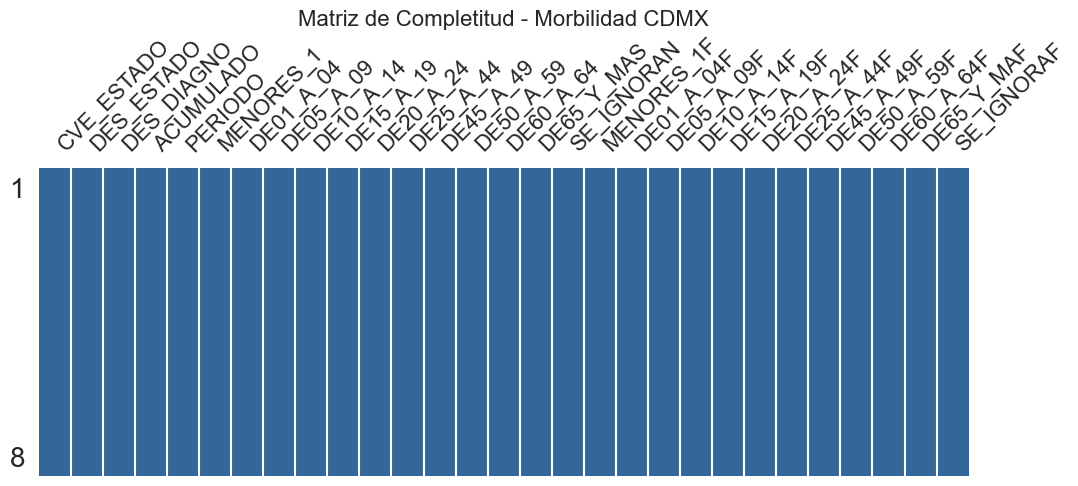

In [7]:
print("--- 1. COMPLETITUD ---")
total_nulos = df_cdmx_morbi.isnull().sum().sum()
print(f"Total de valores nulos en el dataset: {total_nulos}")

# Visualización de la matriz de nulidad (Si el dataset fuera grande, mostraría huecos en blanco)
msno.matrix(df_cdmx_morbi, figsize=(12, 4), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title("Matriz de Completitud - Morbilidad CDMX", fontsize=16)
plt.show()

# *Nota de Perfilado:* Los Anuarios de Morbilidad de la Secretaría de Salud 
# suelen tener imputación por defecto con ceros (0). Si vemos 0 nulos, significa 
# que la base está estructuralmente completa.

#### Validez y Unicidad
Revisaremos que los tipos de datos sean correctos (que las enfermedades no sean números y los casos no sean texto) y que no existan filas duplicadas (error de captura).

In [19]:
print("--- 2. VALIDEZ ---")
# Tipos de datos
print(df_cdmx_morbi.dtypes.value_counts())

# Para abarcar también string 
columnas_string = df_cdmx_morbi.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Columnas de tipo str = {columnas_string}")

# Validar que el PERIODO corresponda a nuestro año esperado (2017)
print(f"\nEl dataset es del 2017 validamos los registros de Años sean registrados en el dataset asi: {df_cdmx_morbi['PERIODO'].unique()}")

print("\n--- 3. UNICIDAD ---")
duplicados = df_cdmx_morbi.duplicated().sum()
print(f"Filas exactamente duplicadas: {duplicados}")

# Verificar si hay diagnósticos duplicados
diag_duplicados = df_cdmx_morbi.duplicated(subset=['DES_DIAGNO']).sum()
print(f"Diagnósticos duplicados: {diag_duplicados}")

--- 2. VALIDEZ ---
int64    27
str       2
Name: count, dtype: int64
Columnas de tipo str = ['DES_ESTADO', 'DES_DIAGNO']

El dataset es del 2017 validamos los registros de Años sean registrados en el dataset asi: [2017]

--- 3. UNICIDAD ---
Filas exactamente duplicadas: 0
Diagnósticos duplicados: 0


#### Consistencia
Si el gobierno nos dice que hubo un ACUMULADO de 100 casos, la suma de los casos de hombres y mujeres de todas las edades tiene que ser exactamente 100.

In [ ]:
print("--- 4. CONSISTENCIA LÓGICA MATEMÁTICA ---")

def es_columna_edad(col):
    # Coincide con "DE" seguido de dígito o guión, o "MENOR", o "SE_IGNORA"
    return bool(re.match(r'^DE[\d\-]', col)) or col.startswith('MENOR') or col.startswith('SE_IGNORA')

# Lista con todas las columnas de grupos de edad (Hombres y Mujeres)
columnas_edad = [col for col in df_cdmx_morbi.columns if es_columna_edad(col)]

# Sumamos horizontalmente las columnas de edad
df_cdmx_morbi['Suma_Validacion'] = df_cdmx_morbi[columnas_edad].sum(axis=1)

# Comparamos la suma calculada vs el ACUMULADO oficial
df_cdmx_morbi['Consistente'] = df_cdmx_morbi['ACUMULADO'] == df_cdmx_morbi['Suma_Validacion']

consistencia_total = df_cdmx_morbi['Consistente'].all()
print(f"¿El ACUMULADO coincide perfectamente con la suma de las edades?: {consistencia_total}")

if not consistencia_total:
    display(df_cdmx_morbi[~df_cdmx_morbi['Consistente']][['DES_DIAGNO', 'ACUMULADO', 'Suma_Validacion']])

--- 4. CONSISTENCIA LÓGICA MATEMÁTICA ---
¿El ACUMULADO coincide perfectamente con la suma de las edades?: True


#### Distribuciones

--- 5. DISTRIBUCIONES Y OUTLIERS ---


C:\Users\PC\AppData\Local\Temp\ipykernel_19484\3433774455.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cdmx_morbi.sort_values('ACUMULADO', ascending=False),


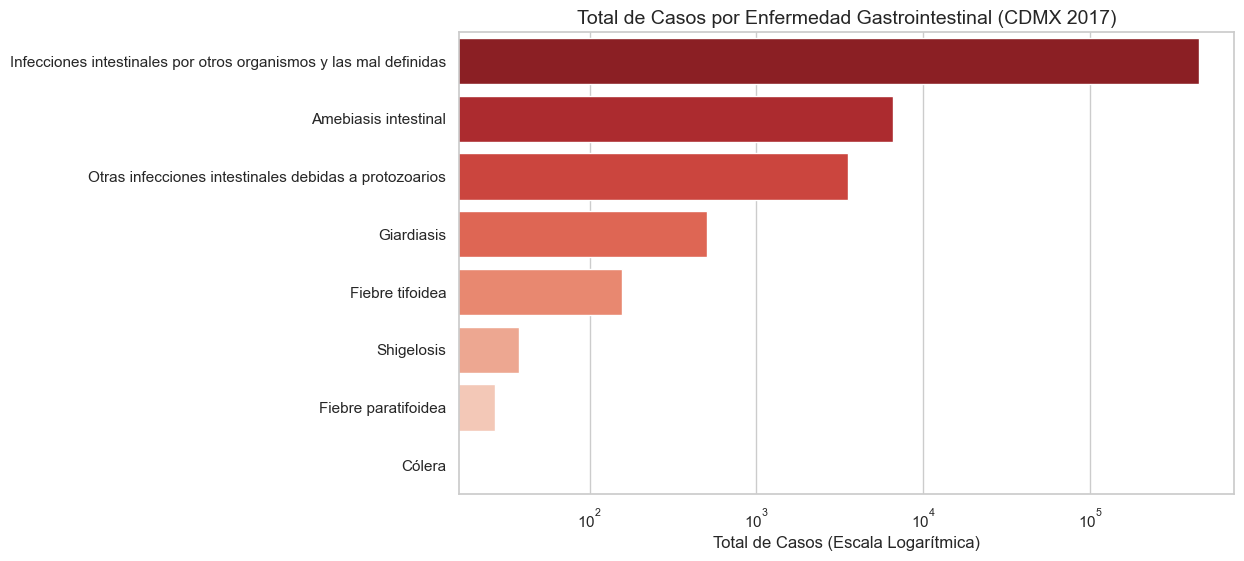

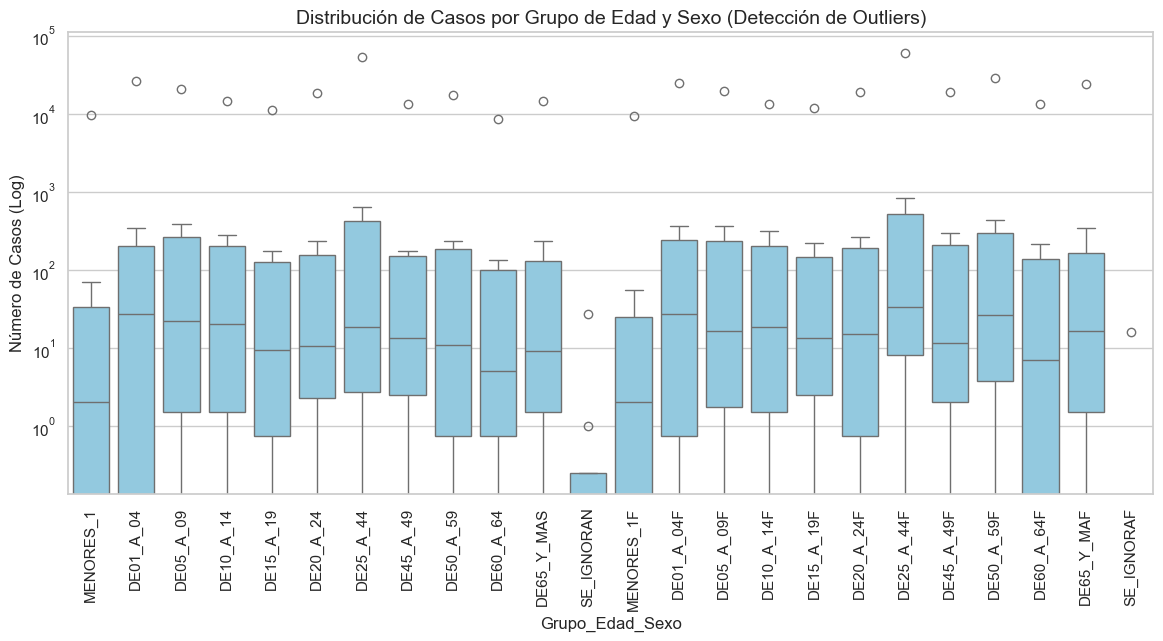

In [21]:
print("--- 5. DISTRIBUCIONES Y OUTLIERS ---")

# Transformar el dataset de formato Ancho a Largo para análisis analítico
df_melted = df_cdmx_morbi.melt(
    id_vars=['DES_DIAGNO'], 
    value_vars=columnas_edad, 
    var_name='Grupo_Edad_Sexo', 
    value_name='Casos'
)

# 1. Gráfico de Barras: ¿Cuáles son las enfermedades más comunes?
plt.figure(figsize=(10, 6))
sns.barplot(data=df_cdmx_morbi.sort_values('ACUMULADO', ascending=False), 
            x='ACUMULADO', y='DES_DIAGNO', palette='Reds_r')
plt.title("Total de Casos por Enfermedad Gastrointestinal (CDMX 2017)", fontsize=14)
plt.xscale('log') # Escala logarítmica porque hay enfermedades de 400 mil casos y otras de 20
plt.xlabel("Total de Casos (Escala Logarítmica)")
plt.ylabel("")
plt.show()

# 2. Boxplot: Distribución de casos por rango de edad
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_melted, x='Grupo_Edad_Sexo', y='Casos', color='skyblue')
plt.title("Distribución de Casos por Grupo de Edad y Sexo (Detección de Outliers)", fontsize=14)
plt.xticks(rotation=90)
plt.yscale('log') # Escala log para ver mejor la distribución
plt.ylabel("Número de Casos (Log)")
plt.show()

#### Correlaciones Tempranas

--- 6. CORRELACIONES TEMPRANAS (Heatmap Enfermedad vs Edad) ---


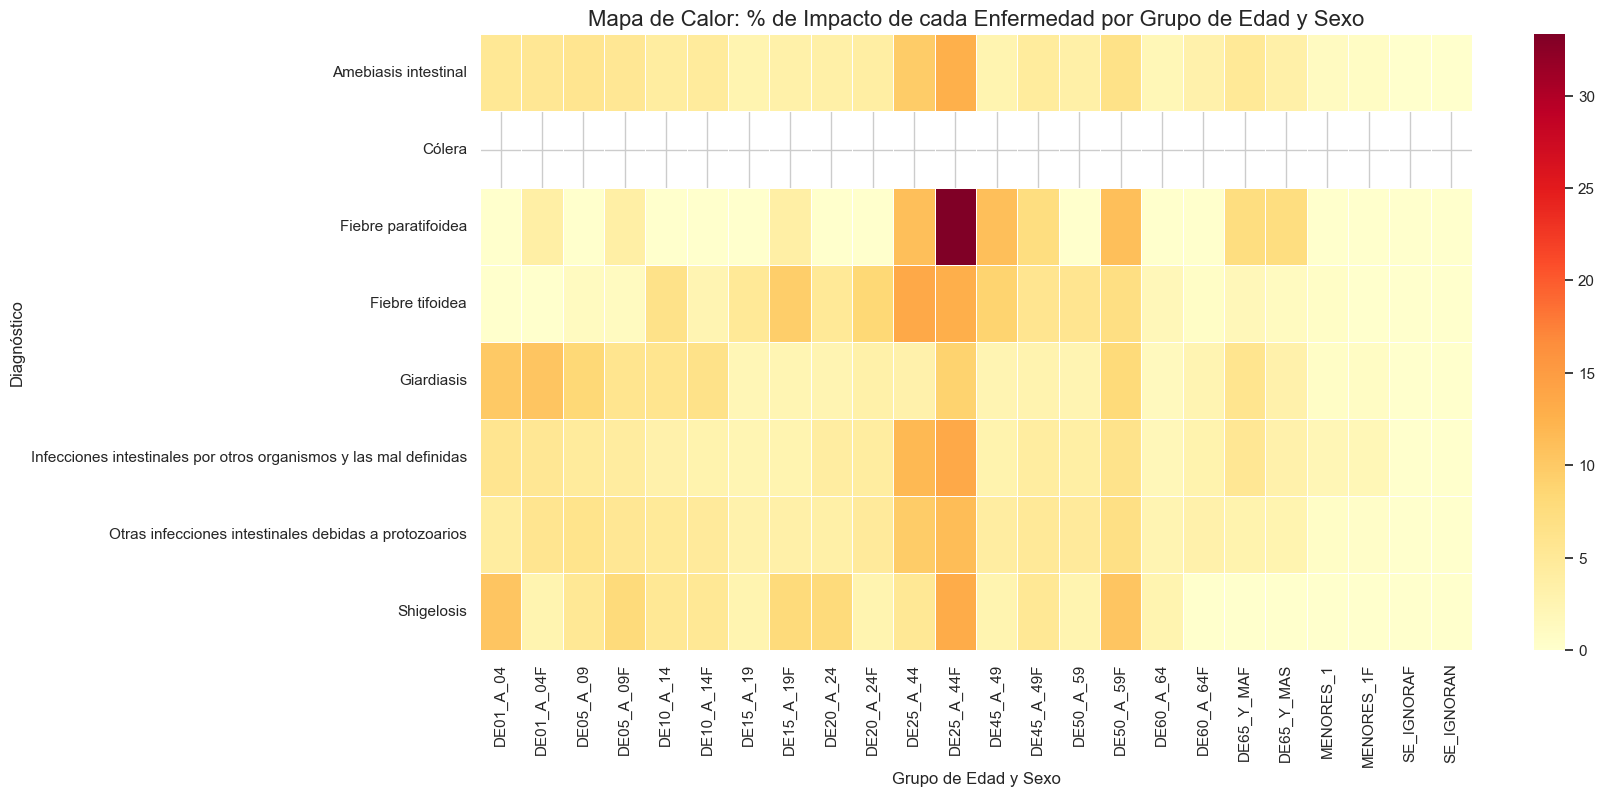

In [22]:
print("--- 6. CORRELACIONES TEMPRANAS (Heatmap Enfermedad vs Edad) ---")

# Preparamos una matriz pivote: Filas = Enfermedades, Columnas = Edades, Valores = Casos
heatmap_data = df_melted.pivot_table(index='DES_DIAGNO', columns='Grupo_Edad_Sexo', values='Casos')

# Para que el heatmap sea legible, normalizamos los datos por fila (porcentaje de afección de cada enfermedad)
heatmap_data_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data_pct, cmap="YlOrRd", annot=False, linewidths=.5)
plt.title("Mapa de Calor: % de Impacto de cada Enfermedad por Grupo de Edad y Sexo", fontsize=16)
plt.xlabel("Grupo de Edad y Sexo")
plt.ylabel("Diagnóstico")
plt.show()

# *Nota de Perfilado:* En este gráfico buscaremos patrones como: "La giardiasis ataca 
# principalmente a niños (DE01_A_04)", lo que es crítico porque los niños son el 
# grupo poblacional más vulnerable ante agua contaminada.

### 4.2 Perfilado INEGI Viviendas

In [34]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset del Censo 2020 (ITER)
# En los datos de INEGI, los valores no calculados o confidenciales suelen venir como '*' o 'N/D'.
# Usamos na_values para convertirlos automáticamente en valores nulos (NaN) para poder operar con ellos.
df_iter = pd.read_csv(ruta_inegi, encoding="utf-8-sig", low_memory=False, na_values=['*', 'N/D', 'N/A'])

# 2. Filtrar por Ciudad de México (ENTIDAD == 9)
# Aseguramos que la columna sea numérica por si fue leída como string ('09')
df_iter['ENTIDAD'] = pd.to_numeric(df_iter['ENTIDAD'], errors='coerce')
df_cdmx_iter = df_iter[df_iter['ENTIDAD'] == 9].copy()

# 3. Definir las columnas a conservar por grupos

# A. Identificadores y Ubicación Geográfica
cols_base = [
    'ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 
    'LONGITUD', 'LATITUD','ALTITUD', 'TAMLOC'
]

# B. Población Total y Franjas de Edad Generales (Sin segmentar por sexo)
cols_pob_edad = [
    'POBTOT', 'POB0_14', 'POB15_64', 'POB65_MAS', 
    'P_0A2', 'P_3A5', 'P_6A11', 'P_12A14', 'P_15A17', 'P_18A24',
    'P_0A4', 'P_5A9', 'P_10A14', 'P_15A19', 'P_20A24', 'P_25A29', 
    'P_30A34', 'P_35A39', 'P_40A44', 'P_45A49', 'P_50A54', 'P_55A59', 
    'P_60A64', 'P_65A69', 'P_70A74', 'P_75A79', 'P_80A84', 'P_85YMAS'
]

# C. Características de Vivienda y Acceso a Agua/Saneamiento
cols_vivienda_agua = [
    'VIVTOT',      # Total de viviendas
    'TVIVPARHAB',  # Total de viviendas particulares habitadas
    'VPH_AGUADV',  # Viviendas part. habitadas con agua entubada DENTRO de la vivienda
    'VPH_AGUAFV',  # Viviendas part. habitadas con agua entubada FUERA de la vivienda, en el terreno
    'VPH_TINACO',  # Viviendas part. habitadas con tinaco (vital para tandeo)
    'VPH_CISTER',  # Viviendas part. habitadas con cisterna
    'VPH_EXCSA',   # Viviendas part. habitadas con excusado o sanitario
    'VPH_DRENAJ',  # Viviendas part. habitadas con drenaje conectado a la red pública
    'VPH_NODREN',  # Viviendas part. habitadas SIN drenaje
    'VPH_C_SERV'   # Viviendas part. habitadas con servicios básicos (Luz, agua y drenaje)
]

# Unir todas las listas en una sola
columnas_finales_iter = cols_base + cols_pob_edad + cols_vivienda_agua

# 4. Filtrar el DataFrame conservando solo las columnas seleccionadas
# Verificamos que las columnas existan en el df original para evitar KeyErrors
columnas_existentes = [col for col in columnas_finales_iter if col in df_cdmx_iter.columns]
df_cdmx_iter = df_cdmx_iter[columnas_existentes]

# 5. (Opcional pero Recomendado) Filtrar Totales
# INEGI incluye filas de resumen donde LOC == 0 (Totales municipales o estatales).
# Si solo vas a mapear puntos específicos (colonias/localidades), debes quitar los totales:
df_cdmx_iter = df_cdmx_iter[df_cdmx_iter['LOC'] > 0]
df_cdmx_iter = df_cdmx_iter[~df_cdmx_iter['LOC'].isin([9998, 9999])]
df_cdmx_iter = df_cdmx_iter.dropna(subset=['LATITUD', 'LONGITUD'])

# Ver el resultado de la limpieza
print(f"Total de localidades/puntos geográficos en CDMX: {df_cdmx_iter.shape[0]}")
df_cdmx_iter.head()

Total de localidades/puntos geográficos en CDMX: 634


,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,TAMLOC,...,VIVTOT,TVIVPARHAB,VPH_AGUADV,VPH_AGUAFV,VPH_TINACO,VPH_CISTER,VPH_EXCSA,VPH_DRENAJ,VPH_NODREN,VPH_C_SERV
52276,9,Ciudad de México,2,Azcapotzalco,1,Azcapotzalco,"99°11'03.698"" W","19°29'02.770"" N",2244,12.0,...,149381,134168.0,133597.0,239.0,107591.0,84062.0,133572.0,133748.0,87.0,133511.0
52278,9,Ciudad de México,3,Coyoacán,1,Coyoacán,"99°09'43.724"" W","19°21'00.770"" N",2247,13.0,...,208024,191517.0,191053.0,133.0,154811.0,114453.0,190834.0,190986.0,182.0,190814.0
52280,9,Ciudad de México,4,Cuajimalpa de Morelos,1,Cuajimalpa de Morelos,"99°17'59.252"" W","19°21'26.461"" N",2780,11.0,...,56986,52524.0,52297.0,124.0,44923.0,21752.0,52233.0,52288.0,104.0,52163.0
52281,9,Ciudad de México,4,Cuajimalpa de Morelos,10,Cruz Blanca,"99°19'26.437"" W","19°19'04.026"" N",2982,3.0,...,224,192.0,189.0,3.0,171.0,25.0,160.0,182.0,10.0,181.0
52282,9,Ciudad de México,4,Cuajimalpa de Morelos,20,San Lorenzo Acopilco,"99°19'32.454"" W","19°19'51.617"" N",2936,8.0,...,7357,6627.0,6554.0,71.0,6239.0,1966.0,6564.0,6601.0,16.0,6530.0


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# 0. PREPARACIÓN (Coerción a numérico)
# Forzamos las columnas demográficas y de vivienda a numérico. 
# Los '*' o 'N/D' que hayan quedado se convertirán en NaN automáticamente con errors='coerce'
cols_pob_viv = [col for col in df_cdmx_iter.columns if col not in ['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'TAMLOC']]

for col in cols_pob_viv:
    df_cdmx_iter[col] = pd.to_numeric(df_cdmx_iter[col], errors='coerce')

--- 1. COMPLETITUD (COMPLETENESS) ---
Total de valores nulos/confidenciales en el dataset: 6308
Porcentaje de datos ocultos en infraestructura de agua (VPH_TINACO): 22.08%



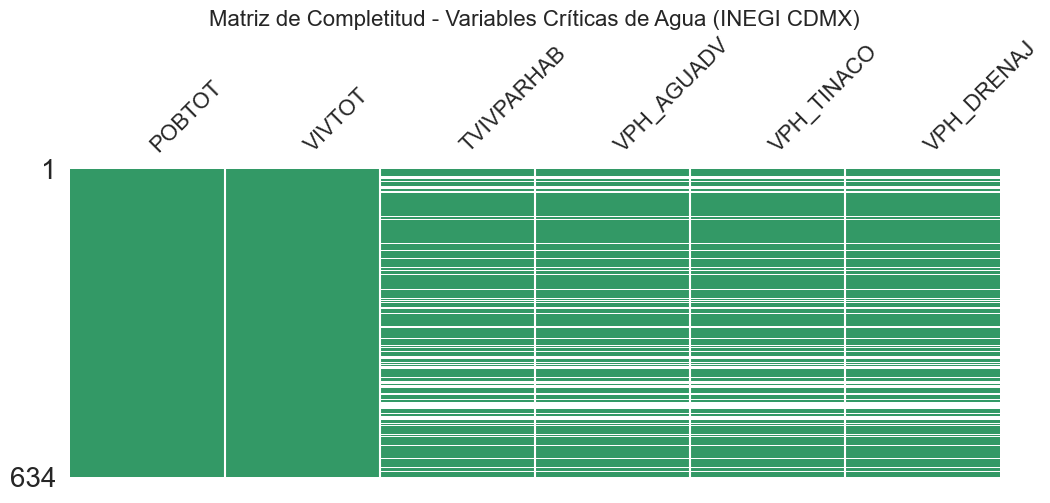

In [36]:
print("--- 1. COMPLETITUD (COMPLETENESS) ---")
total_nulos = df_cdmx_iter.isnull().sum().sum()
print(f"Total de valores nulos/confidenciales en el dataset: {total_nulos}")

# Ver qué porcentaje de la columna VPH_TINACO (vital para nosotros) está oculta
nulos_tinaco = df_cdmx_iter['VPH_TINACO'].isnull().sum()
pct_nulos_tinaco = (nulos_tinaco / len(df_cdmx_iter)) * 100
print(f"Porcentaje de datos ocultos en infraestructura de agua (VPH_TINACO): {pct_nulos_tinaco:.2f}%\n")

# Visualización de la matriz de completitud (mostrará las franjas de censura de INEGI)
msno.matrix(df_cdmx_iter[['POBTOT', 'VIVTOT', 'TVIVPARHAB', 'VPH_AGUADV', 'VPH_TINACO', 'VPH_DRENAJ']], 
            figsize=(12, 4), color=(0.2, 0.6, 0.4), sparkline=False)
plt.title("Matriz de Completitud - Variables Críticas de Agua (INEGI CDMX)", fontsize=16)
plt.show()

In [37]:
print("--- 2. VALIDEZ (VALIDITY) ---")

# A. Validación Espacial (Bounding Box aproximado de la CDMX)
# Latitudes válidas CDMX: ~ 19.0 a 19.6 | Longitudes válidas: ~ -99.4 a -98.9
coords_invalidas = df_cdmx_iter[
    (df_cdmx_iter['LATITUD'] < 19.0) | (df_cdmx_iter['LATITUD'] > 19.6) |
    (df_cdmx_iter['LONGITUD'] < -99.4) | (df_cdmx_iter['LONGITUD'] > -98.9)
]
print(f"Localidades con coordenadas fuera de los límites de la CDMX: {len(coords_invalidas)}")

# B. Validación de Rango (Poblaciones y Viviendas no pueden ser negativas)
negativos = (df_cdmx_iter[cols_pob_viv] < 0).sum().sum()
print(f"Valores negativos en demografía/vivienda (deben ser 0): {negativos}")

print("\n--- 3. UNICIDAD (UNIQUENESS) ---")
# C. En INEGI, la llave primaria es la concatenación de ENTIDAD + MUN + LOC
df_cdmx_iter['CLAVE_GEO'] = df_cdmx_iter['ENTIDAD'].astype(str).str.zfill(2) + \
                            df_cdmx_iter['MUN'].astype(str).str.zfill(3) + \
                            df_cdmx_iter['LOC'].astype(str).str.zfill(4)

duplicados_geo = df_cdmx_iter.duplicated(subset=['CLAVE_GEO']).sum()
print(f"Claves geográficas (Localidades) duplicadas: {duplicados_geo}")

--- 2. VALIDEZ (VALIDITY) ---
Localidades con coordenadas fuera de los límites de la CDMX: 0
Valores negativos en demografía/vivienda (deben ser 0): 0

--- 3. UNICIDAD (UNIQUENESS) ---
Claves geográficas (Localidades) duplicadas: 0


In [38]:
print("--- 4. CONSISTENCIA LÓGICA MATEMÁTICA ---")

# Regla 1: Las viviendas habitadas (TVIVPARHAB) no pueden ser mayores que el total de viviendas (VIVTOT)
inconsistencia_viv = df_cdmx_iter[df_cdmx_iter['TVIVPARHAB'] > df_cdmx_iter['VIVTOT']]
print(f"Regla 1 (TVIVPARHAB <= VIVTOT) - Fallos detectados: {len(inconsistencia_viv)}")

# Regla 2: Las viviendas con agua dentro de la casa no pueden ser mayores a las viviendas habitadas
inconsistencia_agua = df_cdmx_iter[df_cdmx_iter['VPH_AGUADV'] > df_cdmx_iter['TVIVPARHAB']]
print(f"Regla 2 (Agua en Vivienda <= Viv. Habitadas) - Fallos detectados: {len(inconsistencia_agua)}")

# Regla 3: La suma de la población infantil, adulta y mayor no debe superar la POBTOT 
# (inegi tiene "no especificados", así que la suma de rangos de edad es <= POBTOT)
df_cdmx_iter['Suma_Edades_Macro'] = df_cdmx_iter['POB0_14'] + df_cdmx_iter['POB15_64'] + df_cdmx_iter['POB65_MAS']
inconsistencia_pob = df_cdmx_iter[df_cdmx_iter['Suma_Edades_Macro'] > df_cdmx_iter['POBTOT']]
print(f"Regla 3 (Suma de edades macro <= POBTOT) - Fallos detectados: {len(inconsistencia_pob)}")

--- 4. CONSISTENCIA LÓGICA MATEMÁTICA ---
Regla 1 (TVIVPARHAB <= VIVTOT) - Fallos detectados: 0
Regla 2 (Agua en Vivienda <= Viv. Habitadas) - Fallos detectados: 0
Regla 3 (Suma de edades macro <= POBTOT) - Fallos detectados: 0


--- 5. DISTRIBUCIONES Y OUTLIERS ---


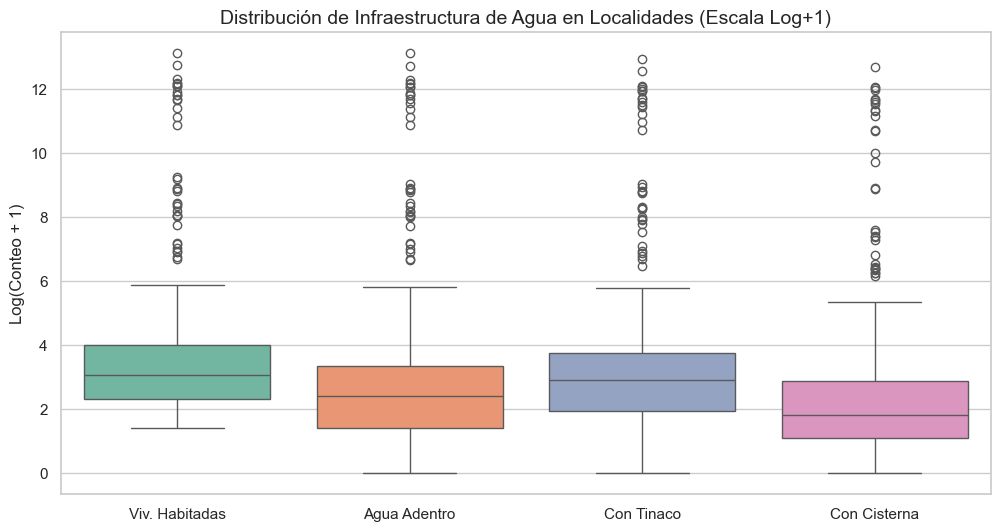

In [39]:
print("--- 5. DISTRIBUCIONES Y OUTLIERS ---")

# Seleccionamos variables críticas de infraestructura hídrica
vars_boxplot = ['TVIVPARHAB', 'VPH_AGUADV', 'VPH_TINACO', 'VPH_CISTER']

plt.figure(figsize=(12, 6))
# Se usa +1 para evitar log(0) que genera infinito
sns.boxplot(data=np.log1p(df_cdmx_iter[vars_boxplot]), palette="Set2")
plt.title("Distribución de Infraestructura de Agua en Localidades (Escala Log+1)", fontsize=14)
plt.ylabel("Log(Conteo + 1)")
plt.xticks(ticks=[0,1,2,3], labels=['Viv. Habitadas', 'Agua Adentro', 'Con Tinaco', 'Con Cisterna'])
plt.show()

# *Nota de Perfilado:* Si la caja de 'VPH_CISTER' está muy por debajo de 'VPH_TINACO', 
# confirmaremos que la CDMX depende críticamente de tinacos superficiales para soportar el tandeo.

--- 6. CORRELACIONES TEMPRANAS (Infraestructura Hídrica) ---


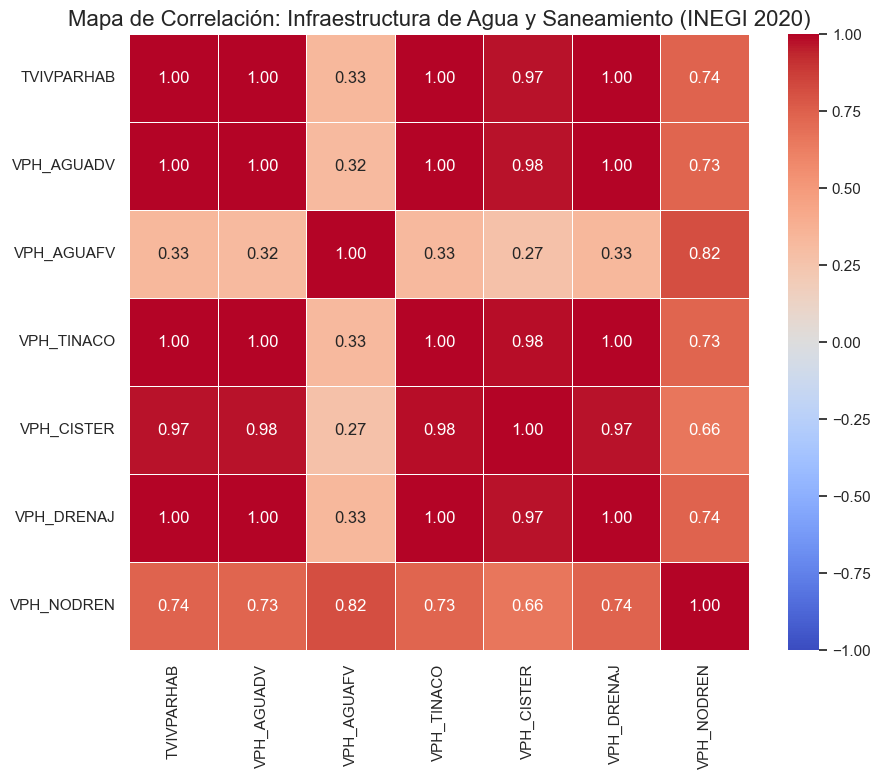

In [40]:
print("--- 6. CORRELACIONES TEMPRANAS (Infraestructura Hídrica) ---")

# Definir las variables de interés (Agua y Saneamiento)
vars_corr = [
    'TVIVPARHAB', 'VPH_AGUADV', 'VPH_AGUAFV', 
    'VPH_TINACO', 'VPH_CISTER', 'VPH_DRENAJ', 'VPH_NODREN'
]

matriz_corr = df_cdmx_iter[vars_corr].corr()

plt.figure(figsize=(10, 8))
# Usamos vmin y vmax para estabilizar la paleta de colores de -1 a 1
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapa de Correlación: Infraestructura de Agua y Saneamiento (INEGI 2020)", fontsize=16)
plt.show()

# *Nota de Perfilado:* Una correlación alta (ej. > 0.90) entre VPH_AGUADV y VPH_DRENAJ 
# indica que la urbanización en la CDMX es integral (te ponen agua y drenaje a la vez). 
# Una correlación negativa fuerte con VPH_NODREN indicaría zonas de extrema precariedad.

### 4.3 Perfilado Pobreza 

In [11]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset de CONEVAL (Pobreza)
# Usamos utf-8, que es el estándar para datos recientes de CONEVAL
df_pobreza = pd.read_csv(ruta_pobreza, encoding="utf-8")

# 2. Filtrar por Ciudad de México (clave_entidad == 9)
# Nos aseguramos de que sea numérico por si viene como texto
df_pobreza['clave_entidad'] = pd.to_numeric(df_pobreza['clave_entidad'], errors='coerce')
df_cdmx_pobreza = df_pobreza[df_pobreza['clave_entidad'] == 9].copy()

# 3. Definir las columnas a conservar según tu requerimiento y la relevancia del proyecto
columnas_finales_pobreza = [
    'clave_entidad', 
    'entidad',                  # Nombre de la entidad (Ciudad de México)
    'clave_municipio', 
    'municipio',                # Nombre de la alcaldía
    'grupo',                    # Grupo de edad poblacional
    'poblacion', 
    'pobreza_porcentaje', 
    'carencia_servicios_basicos_vivienda_porcentaje', # CRÍTICA: Agua, drenaje, luz
    'carencia_calidad_espacios_vivienda_porcentaje',  # CRÍTICA: Hacinamiento, pisos de tierra
    'ingreso_inferior_a_lpi_porcentaje',              # CRÍTICA: Vulnerabilidad económica (Línea de Pobreza por Ingresos)
    'periodo'                   # Año de la medición
]

# 4. Filtrar el DataFrame conservando solo las columnas seleccionadas
df_cdmx_pobreza = df_cdmx_pobreza[columnas_finales_pobreza]

# Ver el resultado de la limpieza
print(f"Total de registros de pobreza por grupos de edad en CDMX: {df_cdmx_pobreza.shape[0]}")
df_cdmx_pobreza.head()

Total de registros de pobreza por grupos de edad en CDMX: 192


,clave_entidad,entidad,clave_municipio,municipio,grupo,poblacion,pobreza_porcentaje,carencia_servicios_basicos_vivienda_porcentaje,carencia_calidad_espacios_vivienda_porcentaje,ingreso_inferior_a_lpi_porcentaje,periodo
273,9,Ciudad de México,9002,Azcapotzalco,"Niñas, niños y adolescentes (0 a 17 años)",86146,33.560905,-999.0,5.716876,46.758250,2020-01-01
274,9,Ciudad de México,9003,Coyoacán,"Niñas, niños y adolescentes (0 a 17 años)",110711,37.442645,-999.0,5.571868,50.530831,2020-01-01
275,9,Ciudad de México,9004,Cuajimalpa de Morelos,"Niñas, niños y adolescentes (0 a 17 años)",49710,43.110548,-999.0,9.453873,54.066137,2020-01-01
276,9,Ciudad de México,9005,Gustavo A. Madero,"Niñas, niños y adolescentes (0 a 17 años)",254802,43.871534,-999.0,6.754873,58.530852,2020-01-01
277,9,Ciudad de México,9006,Iztacalco,"Niñas, niños y adolescentes (0 a 17 años)",82971,34.726554,-999.0,6.547934,44.929632,2020-01-01


### 4.4 Perfilado CONAGUA Resultados

In [22]:
import pandas as pd
import numpy as np

print("Cargando datasets...")
# 1. Cargar los datasets
df_calidad = pd.read_csv(ruta_resultados_conagua, encoding="utf-8-sig", low_memory=False)
df_sitios = pd.read_csv(ruta_sitios_conagua, encoding="utf-8-sig", low_memory=False)

print("Procesando catálogo de Sitios...")
# 2. Limpieza de Coordenadas en Sitios
df_sitios['LATITUD'] = pd.to_numeric(df_sitios['LATITUD'], errors='coerce')
df_sitios['LONGITUD'] = pd.to_numeric(df_sitios['LONGITUD'], errors='coerce')
# Conservamos solo sitios con coordenadas válidas
df_sitios_limpio = df_sitios.dropna(subset=['LATITUD', 'LONGITUD']).copy()

print("Cruzando datos (Merge)...")
# 3. Cruzar (Merge) Resultados con Sitios para tener ESTADO y Coordenadas juntas
df_completo = pd.merge(
    df_calidad, 
    df_sitios_limpio[['CLAVE SITIO', 'ESTADO', 'LATITUD', 'LONGITUD', 'ACUÍFERO', 'CUENCA']], 
    on='CLAVE SITIO', 
    how='left'
)

print("Normalizando texto (quitando acentos) y aplicando filtros...")
# Función para quitar acentos y pasar a mayúsculas usando str.normalize
def normalizar_texto(columna):
    return columna.fillna('').str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper()

# Normalizamos las columnas donde vamos a aplicar los filtros
df_completo['ESTADO_NORM'] = normalizar_texto(df_completo['ESTADO'])
df_completo['SITIO_NORM'] = normalizar_texto(df_completo['NOMBRE DEL SITIO'])
df_completo['ACUIFERO_NORM'] = normalizar_texto(df_completo['ACUÍFERO'])
df_completo['CUENCA_NORM'] = normalizar_texto(df_completo['CUENCA'])

# 4. PRIMER FILTRO: Barreras Geográficas y Tipos de Agua
estados_abastecedores = [
    'CIUDAD DE MEXICO', 'DISTRITO FEDERAL', 'MEXICO', 'MICHOACAN DE OCAMPO', 'MICHOACAN'
]
mask_estado = df_completo['ESTADO_NORM'].isin(estados_abastecedores)

# Solo cuerpos de agua dulce 
tipos_validos = ['SUBTERRÁNEO', 'LÓTICO', 'LÉNTICO']
mask_tipo_agua = df_completo['TIPO CUERPO DE AGUA'].str.upper().isin(tipos_validos)

# Excluimos sitios que son de drenaje, desagüe o descargas
mask_no_drenaje = ~df_completo['SITIO_NORM'].str.contains('TECAMACHALCO|TUNEL|DESCARGA|EMISOR|DREN', na=False)

# 5. SEGUNDO FILTRO: Palabras clave de nuestras fuentes
fuentes_cdmx_keywords = [
    # Cutzamala
    'CUTZAMALA', 'VALLE DE BRAVO', 'VILLA VICTORIA', 'EL BOSQUE', 'COLORINES', 
    'LOS BERROS', 'CHILESDO',
    # Lerma
    'LERMA', 'ALMOLOYA', 'CHIGNAHUAPAN', 'TOLUCA', 'ATLACOMULCO', 'IXTLAHUACA', 
    'ZINACANTEPEC', 'METEPEC',
    # Valle de México
    'TEXCOCO', 'CHALCO', 'AMECAMECA', 'NABOR CARRILLO', 'XOCHIMILCO', 
    'SAN GREGORIO', 'ZUMPANGO', 'MADIN', 'TEPOTZOTLAN', 'TEOLOYUCAN', 
    'MIXQUIC', 'TLAHUAC', 'SANTA CATARINA', 'PRESA LA CONCEPCION', 'PRESA GUADALUPE'
]

regex_fuentes = '|'.join(fuentes_cdmx_keywords)

mask_fuentes = (
    df_completo['SITIO_NORM'].str.contains(regex_fuentes) |
    df_completo['ACUIFERO_NORM'].str.contains(regex_fuentes) |
    df_completo['CUENCA_NORM'].str.contains(regex_fuentes)
)

# 6. Aplicar todos los filtros juntos
df_calidad_cdmx = df_completo[mask_estado & mask_tipo_agua & mask_no_drenaje & mask_fuentes].copy()

print("Seleccionando columnas críticas y limpiando mediciones...")
# 7. Selección de Columnas Críticas (incluyendo las originales, no las normalizadas para el reporte final)
columnas_finales = [
    'CLAVE SITIO', 'NOMBRE DEL SITIO', 'TIPO CUERPO DE AGUA', 'ESTADO', 
    'LATITUD', 'LONGITUD', 'FECHA REALIZACIÓN', 'Año',
    'E_COLI', 'COLI_FEC', 'COLI_TOT', 'AS_TOT', 'PB_TOT', 'HG_TOT', 
    'CD_TOT', 'FLUORUROS_TOT', 'N_NO3', 'DBO_TOT', 'DQO_TOT', 'SST', 'ALC_TOT'
]

# Asegurar que solo filtramos las columnas que existen
columnas_existentes = [col for col in columnas_finales if col in df_calidad_cdmx.columns]
df_calidad_cdmx = df_calidad_cdmx[columnas_existentes]
"""
# 8. Limpieza de datos numéricos químicos (quitar '<', 'ND')
def limpiar_medicion(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip().replace(',', '')
    if val.startswith('<') or val.startswith('>'):
        val = val[1:] 
    if val in ['ND', 'N/D', 'NA']:
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

columnas_mediciones = [
    'E_COLI', 'COLI_FEC', 'COLI_TOT', 'AS_TOT', 'PB_TOT', 'HG_TOT', 
    'CD_TOT', 'FLUORUROS_TOT', 'N_NO3', 'DBO_TOT', 'DQO_TOT', 'SST', 'ALC_TOT'
]

for col in columnas_mediciones:
    if col in df_calidad_cdmx.columns:
        df_calidad_cdmx[col] = df_calidad_cdmx[col].apply(limpiar_medicion)
"""

print(f"¡Listo! Total de registros históricos purificados para la CDMX: {df_calidad_cdmx.shape[0]}")

# Opcional: Exportar el CSV limpio
# df_calidad_cdmx.to_csv("Calidad_Agua_CDMX_Limpio.csv", index=False, encoding="utf-8-sig")

df_calidad_cdmx.head()

Cargando datasets...
Procesando catálogo de Sitios...
Cruzando datos (Merge)...
Normalizando texto (quitando acentos) y aplicando filtros...
Seleccionando columnas críticas y limpiando mediciones...
¡Listo! Total de registros históricos purificados para la CDMX: 1672


,CLAVE SITIO,NOMBRE DEL SITIO,TIPO CUERPO DE AGUA,ESTADO,LATITUD,LONGITUD,FECHA REALIZACIÓN,Año,E_COLI,COLI_FEC,...,AS_TOT,PB_TOT,HG_TOT,CD_TOT,FLUORUROS_TOT,N_NO3,DBO_TOT,DQO_TOT,SST,ALC_TOT
19352,DLGUA1024,DERIVADORA MARKAZUZA,LÉNTICO,MICHOACÁN DE OCAMPO,20.32435,-101.46089,41415,2013,>2400,>2400,...,<0.0015,0.018,0.0013,<0.001301,NaN,<0.031,35,71,11,NaN
19353,DLGUA1024,DERIVADORA MARKAZUZA,LÉNTICO,MICHOACÁN DE OCAMPO,20.32435,-101.46089,41512,2013,150,150,...,0.004,<0.00154,0.0004,<0.001301,NaN,0.19,3,47,20,NaN
19354,DLGUA1024,DERIVADORA MARKAZUZA,LÉNTICO,MICHOACÁN DE OCAMPO,20.32435,-101.46089,41695,2014,11000,11000,...,0.0016,<0.00154,0.000774,<0.001301,NaN,0.492,14,29,<10,NaN
19355,DLGUA1024,DERIVADORA MARKAZUZA,LÉNTICO,MICHOACÁN DE OCAMPO,20.32435,-101.46089,41835,2014,>24000,>24000,...,0.0017,0.003,0.00073,3e-05,NaN,0.67,17,78,130,NaN
19356,DLGUA1024,DERIVADORA MARKAZUZA,LÉNTICO,MICHOACÁN DE OCAMPO,20.32435,-101.46089,42074,2015,150,460,...,0.0017,<0.00154,0.000139,4e-05,NaN,0.2,17,72,42,NaN


### 4.5 Perfilado CONAGUA Sitios

In [24]:
import pandas as pd
import numpy as np

print("Cargando el catálogo de Sitios...")
# 1. Cargar el dataset
df_sitios = pd.read_csv(ruta_sitios_conagua, encoding="utf-8-sig", low_memory=False)

print("Limpiando coordenadas geográficas...")
# 2. Asegurar que Latitud y Longitud sean números puros
df_sitios['LATITUD'] = pd.to_numeric(df_sitios['LATITUD'], errors='coerce')
df_sitios['LONGITUD'] = pd.to_numeric(df_sitios['LONGITUD'], errors='coerce')

# Conservamos solo sitios con coordenadas válidas (indispensable para mapear)
df_sitios_limpio = df_sitios.dropna(subset=['LATITUD', 'LONGITUD']).copy()

print("Normalizando texto para el filtrado a prueba de errores...")
# 3. Función de normalización (quita acentos y pasa a mayúsculas)
def normalizar_texto(columna):
    return columna.fillna('').str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper()

# Crear columnas auxiliares para buscar sin preocuparnos por acentos
df_sitios_limpio['ESTADO_NORM'] = normalizar_texto(df_sitios_limpio['ESTADO'])
df_sitios_limpio['SITIO_NORM'] = normalizar_texto(df_sitios_limpio['NOMBRE DEL SITIO'])
df_sitios_limpio['ACUIFERO_NORM'] = normalizar_texto(df_sitios_limpio['ACUÍFERO'])
df_sitios_limpio['CUENCA_NORM'] = normalizar_texto(df_sitios_limpio['CUENCA'])
df_sitios_limpio['TIPO_AGUA_NORM'] = normalizar_texto(df_sitios_limpio['TIPO DE CUERPO DE AGUA'])

print("Aplicando barreras y filtros...")
# 4. PRIMER FILTRO: Geografía y Tipos de Agua
estados_abastecedores = [
    'CIUDAD DE MEXICO', 'DISTRITO FEDERAL', 'MEXICO', 'MICHOACAN DE OCAMPO', 'MICHOACAN', 'ESTADO DE MEXICO'
]
mask_estado = df_sitios_limpio['ESTADO_NORM'].isin(estados_abastecedores)

# Como ya normalizamos, buscamos las palabras sin acentos (LÓTICO -> LOTICO)
tipos_validos = ['SUBTERRANEO', 'LOTICO', 'LENTICO']
mask_tipo_agua = df_sitios_limpio['TIPO_AGUA_NORM'].isin(tipos_validos)

# Filtro anti-drenaje
mask_no_drenaje = ~df_sitios_limpio['SITIO_NORM'].str.contains('TECAMACHALCO|TUNEL|DESCARGA|EMISOR|DREN', na=False)

# 5. SEGUNDO FILTRO: Palabras clave de nuestras fuentes
fuentes_cdmx_keywords = [
    'CUTZAMALA', 'VALLE DE BRAVO', 'VILLA VICTORIA', 'EL BOSQUE', 'COLORINES', 
    'LOS BERROS', 'CHILESDO', 'LERMA', 'ALMOLOYA', 'CHIGNAHUAPAN', 'TOLUCA', 
    'ATLACOMULCO', 'IXTLAHUACA', 'ZINACANTEPEC', 'METEPEC', 'TEXCOCO', 'CHALCO', 
    'AMECAMECA', 'NABOR CARRILLO', 'XOCHIMILCO', 'SAN GREGORIO', 'ZUMPANGO', 
    'MADIN', 'TEPOTZOTLAN', 'TEOLOYUCAN', 'MIXQUIC', 'TLAHUAC', 'SANTA CATARINA', 
    'PRESA LA CONCEPCION', 'PRESA GUADALUPE'
]
regex_fuentes = '|'.join(fuentes_cdmx_keywords)

mask_fuentes = (
    df_sitios_limpio['SITIO_NORM'].str.contains(regex_fuentes) |
    df_sitios_limpio['ACUIFERO_NORM'].str.contains(regex_fuentes) |
    df_sitios_limpio['CUENCA_NORM'].str.contains(regex_fuentes)
)

# 6. Aplicar el filtrado definitivo
df_sitios_cdmx = df_sitios_limpio[mask_estado & mask_tipo_agua & mask_no_drenaje & mask_fuentes].copy()

# 7. Limpiar la "basura" (Borrar columnas auxiliares)
columnas_auxiliares = ['ESTADO_NORM', 'SITIO_NORM', 'ACUIFERO_NORM', 'CUENCA_NORM', 'TIPO_AGUA_NORM']
df_sitios_cdmx = df_sitios_cdmx.drop(columns=columnas_auxiliares)

print(f"¡Éxito! Total de sitios de monitoreo catalogados para las fuentes de la CDMX: {df_sitios_cdmx.shape[0]}")

# Opcional: Exportar el catálogo limpio
# df_sitios_cdmx.to_csv("Sitios_CONAGUA_CDMX_Limpio.csv", index=False, encoding="utf-8-sig")

df_sitios_cdmx.head()

Cargando el catálogo de Sitios...
Limpiando coordenadas geográficas...
Normalizando texto para el filtrado a prueba de errores...
Aplicando barreras y filtros...
¡Éxito! Total de sitios de monitoreo catalogados para las fuentes de la CDMX: 171


,CLAVE SITIO,NOMBRE DEL SITIO,CUENCA,CLAVE ACUÍFERO,ACUÍFERO,ORGANISMO CUENCA,DIRECCIÓN LOCAL,ESTADO,MUNICIPIO,CUERPO DE AGUA,TIPO DE CUERPO DE AGUA,SUBTIPO CUERPO AGUA,LATITUD,LONGITUD
1142,DLEST5371,POZO DE PARQUE INDUSTRIAL TOLUCA 2000,NaN,1501.0,VALLE DE TOLUCA,LERMA SANTIAGO PACÍFICO,ESTADO DE MÉXICO,ESTADO DE MÉXICO,TOLUCA,ACUÍFERO VALLE DE TOLUCA,SUBTERRÁNEO,POZO,19.265198,-99.636214
1143,DLEST5373,POZO SANTA MARIA CANCHESDA,NaN,1502.0,IXTLAHUACA-ATLACOMULCO,LERMA SANTIAGO PACÍFICO,ESTADO DE MÉXICO,ESTADO DE MÉXICO,TEMASCALCINGO,ACUÍFERO IXTLAHUACA-ATLACOMULCO,SUBTERRÁNEO,POZO,19.853333,-100.055556
1144,DLEST5374,POZO NO. 2 EMPRESA LIQUIMEX S.A DE C.V. (BONAF...,NaN,1501.0,VALLE DE TOLUCA,LERMA SANTIAGO PACÍFICO,ESTADO DE MÉXICO,ESTADO DE MÉXICO,TOLUCA,ACUÍFERO VALLE DE TOLUCA,SUBTERRÁNEO,POZO,19.328889,-99.571667
1145,DLEST5375,"MAHLE COMPONENTES DE MOTOR DE MEXICO, S. DE R....",NaN,1501.0,VALLE DE TOLUCA,LERMA SANTIAGO PACÍFICO,ESTADO DE MÉXICO,ESTADO DE MÉXICO,LERMA,ACUÍFERO VALLE DE TOLUCA,SUBTERRÁNEO,POZO,19.296667,-99.535556
1146,DLEST6147,SITIO NO. 11 NORIA IMSS,NaN,1501.0,VALLE DE TOLUCA,LERMA SANTIAGO PACÍFICO,MÉXICO,ESTADO DE MÉXICO,ZINACANTEPEC,ACUÍFERO VALLE DE TOLUCA,SUBTERRÁNEO,NORIA,19.290975,-99.733256


### 4.6 Perfilado Reportes Agua

In [25]:
df_cdmx_iter.columns.tolist()

['ENTIDAD',
 'NOM_ENT',
 'MUN',
 'NOM_MUN',
 'LOC',
 'NOM_LOC',
 'LONGITUD',
 'LATITUD',
 'ALTITUD',
 'TAMLOC',
 'POBTOT',
 'POB0_14',
 'POB15_64',
 'POB65_MAS',
 'P_0A2',
 'P_3A5',
 'P_6A11',
 'P_12A14',
 'P_15A17',
 'P_18A24',
 'P_0A4',
 'P_5A9',
 'P_10A14',
 'P_15A19',
 'P_20A24',
 'P_25A29',
 'P_30A34',
 'P_35A39',
 'P_40A44',
 'P_45A49',
 'P_50A54',
 'P_55A59',
 'P_60A64',
 'P_65A69',
 'P_70A74',
 'P_75A79',
 'P_80A84',
 'P_85YMAS',
 'VIVTOT',
 'TVIVPARHAB',
 'VPH_AGUADV',
 'VPH_AGUAFV',
 'VPH_TINACO',
 'VPH_CISTER',
 'VPH_EXCSA',
 'VPH_DRENAJ',
 'VPH_NODREN',
 'VPH_C_SERV']